In [108]:
!python --version

Python 3.11.9


In [109]:
%matplotlib inline

In [110]:
import os

def define_auth():
    os.environ["HF_TOKEN"] = ""

In [111]:
import pandas as pd

def get_dataset(type="train"):
    splits = {'train': 'train_meta.csv', 'test': 'test_meta.csv'}
    df = pd.read_csv("hf://datasets/lasfk/EEG-fNIRS-based-Handwriting-Trajectory-Dataset/" + splits[type])
    return df

In [112]:
def read_bdf(subject, session):
    path = f"datasets/raw/{subject}/EEG/{session}.bdf"
    raw = mne.io.read_raw_bdf(path, preload=True)
    return raw

In [113]:
import numpy as np

from asrpy import ASR

def clean_bdf(raw):
    empty_channels = [
    'Fpz',
    'Fp1',
    'Fp2',
    'AF3',
    'AF4',
    'AF7',
    'AF8',
    'F7',
    'F8',
    'FT7',
    'FT8',
    'T7',
    'T8',
    'TP7',
    'TP8',
    'Pz',
    'P3',
    'P4',
    'P5',
    'P6',
    'P7',
    'P8',
    'POz',
    'PO3',
    'PO4',
    'PO5',
    'PO6',
    'PO7',
    'PO8',
    'Oz',
    'O1',
    'O2',
    'ECG',
    'HEOR',
    'HEOL',
    'VEOU',
    'VEOL',
    ]
    raw.drop_channels(empty_channels)

def segmentation_eeg(raw, onset_sec, label, tmin, tmax):
    sfreq = raw.info["sfreq"]
    start_sample = int((onset_sec + tmin) * sfreq)
    end_sample = int((onset_sec + tmax) * sfreq)
    
    segment = raw.get_data(
        start=start_sample,
        stop=end_sample
    )

    expected_length = int((tmax - tmin) * sfreq)

    # Skip broken segment
    if segment.shape[1] != expected_length:
        return [], -1

    return segment, label

def normalize_channel(X):
    X_norm = np.zeros_like(X)

    for i in range(X.shape[0]):
    
        for ch in range(X.shape[1]):
    
            signal = X[i, ch]
    
            mean = signal.mean()
            std = signal.std()
    
            if std == 0:
                std = 1e-8
    
            X_norm[i, ch] = (signal - mean) / std
    return X_norm

def asr_remove(raw):
    sfreq = raw.info["sfreq"]
    asr = ASR(
        sfreq=sfreq,
        cutoff=20
    )
    asr.fit(raw)
    clean_data = asr.transform(raw)
    return mne.io.RawArray(clean_data, raw.info)

def preprocessing_bdf(raw):
    clean_bdf(raw)

    # Buang sinyal listrik
    raw.notch_filter(50)

    # Band Pass 1Hz~45Hz, Band EEG umum => Delta, Theta, Alpha, Beta, Gamma (1 - 45)Hz
    raw.filter(0.5, 45)
    return raw

In [114]:
define_auth()
df_train = get_dataset()

In [125]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

mne.set_log_level("ERROR")
montage = mne.channels.make_standard_montage(
    "standard_1020"
)
EEG_TMIN = 0.0
EEG_TMAX = 2.0

EVENT_ID = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3
}

MOTOR_CHANNELS = [
    # Frontal
    "Fz", "F1", "F2", "F3", "F4", "F5", "F6",

    # Fronto-central
    "FCz", "FC1", "FC2", "FC3", "FC4", "FC5", "FC6",

    # Central
    "Cz", "C1", "C2", "C3", "C4", "C5", "C6",

    # Centro-parietal
    "CP1", "CP2", "CP3", "CP4", "CP5", "CP6"
]

def build_subject_epochs(subject):
    subject_df = df_train[
        df_train["subject"] == subject
    ]
    
    sessions = sorted(
        subject_df["session"].unique()
    )
    
    raw_list = []
    all_events = []
    offset = 0

    print(f"Processing session: {len(sessions)}")
    for session in sessions:
        print(f"Getting ERP, session={session}")
        raw = read_bdf(subject, session)
    
        raw.load_data()
        raw.set_montage(
            montage,
            on_missing="ignore"
        )

        raw.set_eeg_reference(
            "average"
        )
    
        raw = preprocessing_bdf(raw)
    
        session_df = subject_df[
            subject_df["session"] == session
        ]
    
        for _, row in session_df.iterrows():
    
            onset_sec = row["onset_sec"]
    
            label = int(
                row["label"]
            )
    
            onset_sample = int(
                onset_sec * raw.info["sfreq"]
            )
    
            onset_sample += offset
    
            all_events.append(
                [
                    onset_sample,
                    0,
                    label
                ]
            )
    
        offset += raw.n_times
        raw_list.append(raw)
    
    raw_concat = mne.concatenate_raws(
        raw_list
    )
    
    events = np.array(all_events)
    epochs = mne.Epochs(
        raw_concat,
        events,
        event_id=EVENT_ID,
        tmin=EEG_TMIN,
        tmax=EEG_TMAX,
        baseline=None,
        preload=True
    )
    epochs_motor = epochs.copy().pick(
        MOTOR_CHANNELS
    )
    return epochs_motor


  0%|                                                                                                                                                                                                      | 0/20 [00:00<?, ?it/s]


Processing Subject sub_01
Processing session: 9
Getting ERP, session=1
Getting ERP, session=2
Getting ERP, session=3
Getting ERP, session=4
Getting ERP, session=5
Getting ERP, session=6
Getting ERP, session=7
Getting ERP, session=8
Getting ERP, session=9


  5%|█████████▌                                                                                                                                                                                    | 1/20 [00:19<06:08, 19.37s/it]


Processing Subject sub_02
Processing session: 9
Getting ERP, session=1
Getting ERP, session=2
Getting ERP, session=3
Getting ERP, session=4
Getting ERP, session=5
Getting ERP, session=6
Getting ERP, session=7
Getting ERP, session=8
Getting ERP, session=9


 10%|███████████████████                                                                                                                                                                           | 2/20 [00:40<06:02, 20.11s/it]

...

 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                   | 18/20 [06:17<00:44, 22.01s/it]


Processing Subject sub_19
Processing session: 9
Getting ERP, session=1
Getting ERP, session=2
Getting ERP, session=3
Getting ERP, session=4
Getting ERP, session=5
Getting ERP, session=6
Getting ERP, session=7
Getting ERP, session=8
Getting ERP, session=9


 95%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌         | 19/20 [06:37<00:21, 21.64s/it]


Processing Subject sub_20
Processing session: 8
Getting ERP, session=1
Getting ERP, session=2
Getting ERP, session=3
Getting ERP, session=4
Getting ERP, session=5
Getting ERP, session=6
Getting ERP, session=7
Getting ERP, session=8


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [06:56<00:00, 20.82s/it]


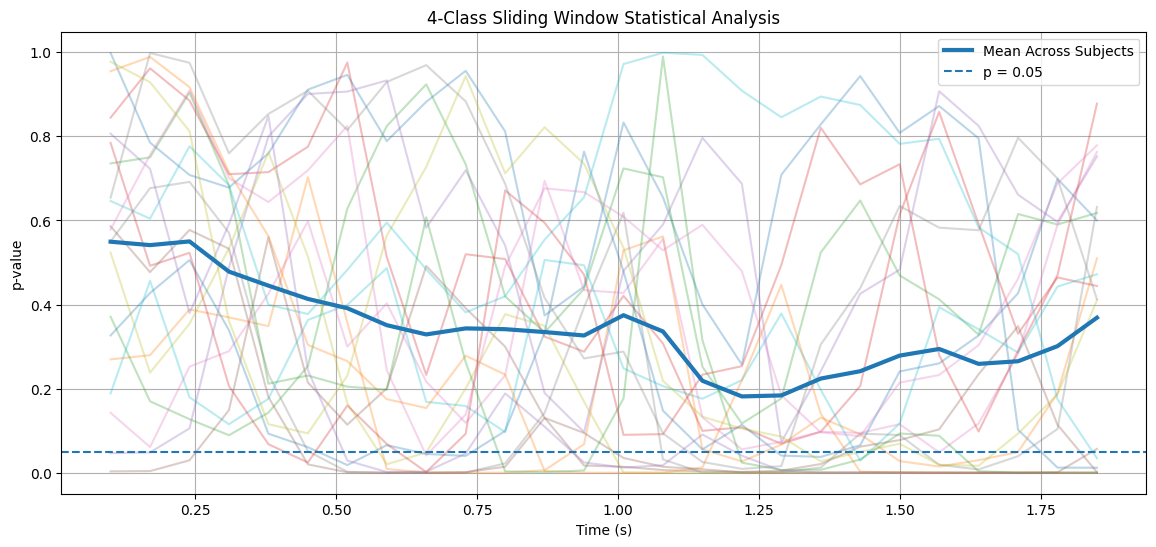

In [127]:
from tqdm import tqdm
from scipy.stats import kruskal

all_subject_pvalues = []

subjects = sorted(
    df_train["subject"].unique()
)
WINDOW_SIZE = 0.2
STEP_SIZE = 0.07

for subject in tqdm(subjects, total=len(subjects)):
    print(f"\nProcessing Subject {subject}")

    epochs_motor = build_subject_epochs(subject)
    picks = mne.pick_channels(
        epochs_motor.ch_names,
        include=MOTOR_CHANNELS
    )

    times = epochs_motor.times

    # -----------------------------------------------------
    # GET CLASS DATA
    # -----------------------------------------------------

    data_0 = epochs_motor["0"].get_data()
    data_1 = epochs_motor["1"].get_data()
    data_2 = epochs_motor["2"].get_data()
    data_3 = epochs_motor["3"].get_data()

    subject_pvalues = []
    window_centers = []

    # =====================================================
    # SLIDING WINDOW
    # =====================================================

    for start in np.arange(
        times[0],
        times[-1] - WINDOW_SIZE,
        STEP_SIZE
    ):

        end = start + WINDOW_SIZE

        mask = (
            (times >= start)
            &
            (times <= end)
        )

        # -------------------------------------------------
        # WINDOW EXTRACTION
        # -------------------------------------------------

        win_0 = data_0[:, picks, :][:, :, mask]
        win_1 = data_1[:, picks, :][:, :, mask]
        win_2 = data_2[:, picks, :][:, :, mask]
        win_3 = data_3[:, picks, :][:, :, mask]

        # -------------------------------------------------
        # FEATURE
        # mean(channel + time)
        # -------------------------------------------------

        feat_0 = win_0.mean(axis=(1, 2))
        feat_1 = win_1.mean(axis=(1, 2))
        feat_2 = win_2.mean(axis=(1, 2))
        feat_3 = win_3.mean(axis=(1, 2))

        # -------------------------------------------------
        # KRUSKAL-WALLIS
        # -------------------------------------------------

        stat, p = kruskal(
            feat_0,
            feat_1,
            feat_2,
            feat_3
        )

        subject_pvalues.append(p)

        window_centers.append(
            start + WINDOW_SIZE / 2
        )

    all_subject_pvalues.append(
        subject_pvalues
    )

# =========================================================
# MEAN ACROSS SUBJECTS
# =========================================================

all_subject_pvalues = np.array(
    all_subject_pvalues
)

mean_pvalues = all_subject_pvalues.mean(axis=0)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(14, 6))

# individual subject
for subj_p in all_subject_pvalues:

    plt.plot(
        window_centers,
        subj_p,
        alpha=0.3
    )

# mean
plt.plot(
    window_centers,
    mean_pvalues,
    linewidth=3,
    label="Mean Across Subjects"
)

# significance threshold
plt.axhline(
    0.05,
    linestyle="--",
    label="p = 0.05"
)

plt.xlabel("Time (s)")
plt.ylabel("p-value")

plt.title(
    "4-Class Sliding Window Statistical Analysis"
)

plt.legend()

plt.grid()

plt.show()


Epochs:
<Epochs | 324 events (all good), 0 – 2 s (baseline off), ~133.6 MiB, data loaded,
 '0': 81
 '1': 81
 '2': 81
 '3': 81>

Motor epochs:
<Epochs | 324 events (all good), 0 – 2 s (baseline off), ~133.6 MiB, data loaded,
 '0': 81
 '1': 81
 '2': 81
 '3': 81>
ERP_0


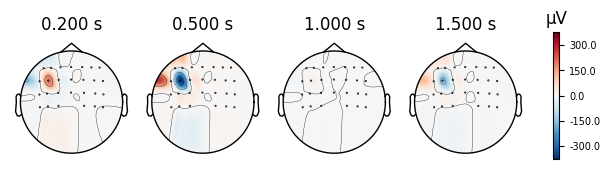

ERP_1


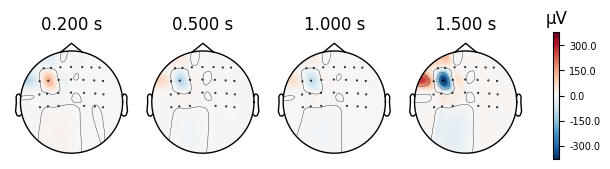

ERP_2


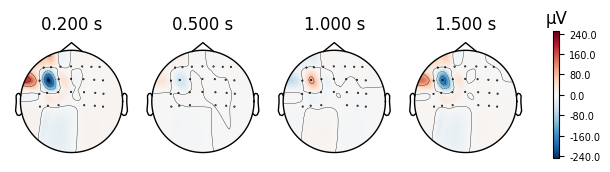

ERP_3


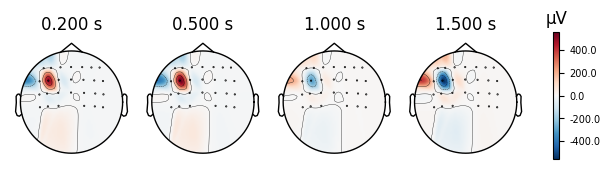

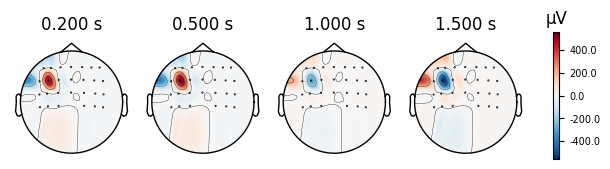

In [106]:
# =========================================================
# EPOCHING
# =========================================================
EEG_TMIN = 0.0
EEG_TMAX = 2.0

epochs = mne.Epochs(
    raw_concat,
    events,
    event_id=EVENT_ID,
    tmin=EEG_TMIN,
    tmax=EEG_TMAX,
    baseline=None,
    preload=True
)

print("\nEpochs:")
print(epochs)

# =========================================================
# KEEP ONLY MOTOR CHANNELS
# =========================================================

epochs_motor = epochs.copy().pick(
    MOTOR_CHANNELS
)

print("\nMotor epochs:")
print(epochs_motor)

# =========================================================
# ERP PER TRAJECTORY
# =========================================================

erp_0 = epochs_motor["0"].average()
erp_1 = epochs_motor["1"].average()
erp_2 = epochs_motor["2"].average()
erp_3 = epochs_motor["3"].average()

print("ERP_0")
erp_0.plot_topomap(
    times=[0.2, 0.5, 1.0, 1.5],
    ch_type="eeg"
)
print("ERP_1")
erp_1.plot_topomap(
    times=[0.2, 0.5, 1.0, 1.5],
    ch_type="eeg"
)
print("ERP_2")
erp_2.plot_topomap(
    times=[0.2, 0.5, 1.0, 1.5],
    ch_type="eeg"
)
print("ERP_3")
erp_3.plot_topomap(
    times=[0.2, 0.5, 1.0, 1.5],
    ch_type="eeg"
)

In [ ]:

# =========================================================
# ERP VISUALIZATION
# =========================================================

mne.viz.plot_compare_evokeds(
    {
        "trajectory_0": erp_0,
        "trajectory_1": erp_1,
        "trajectory_2": erp_2,
        "trajectory_3": erp_3
    },
    combine="mean"
)

# =========================================================
# SINGLE CHANNEL VIEW
# =========================================================

mne.viz.plot_compare_evokeds(
    {
        "trajectory_0": erp_0,
        "trajectory_1": erp_1,
        "trajectory_2": erp_2,
        "trajectory_3": erp_3
    },
    picks=["CP3"]
)

# =========================================================
# ERP WINDOW
# =========================================================

WINDOW_START = 0.4
WINDOW_END = 1.0

print("\nERP Window:")
print(WINDOW_START, WINDOW_END)

# =========================================================
# ERP FEATURE EXTRACTION
# =========================================================

def extract_erp_features(
    erp,
    window_start,
    window_end
):

    # -----------------------------------------------------
    # ERP TIME AXIS
    # -----------------------------------------------------

    times = erp.times

    # -----------------------------------------------------
    # TIME MASK
    # -----------------------------------------------------

    mask = (
        (times >= window_start)
        &
        (times <= window_end)
    )

    # -----------------------------------------------------
    # ERP DATA
    # shape:
    # (channels, times)
    # -----------------------------------------------------

    erp_data = erp.data

    # -----------------------------------------------------
    # TAKE ONLY WINDOW
    # -----------------------------------------------------

    window_data = erp_data[:, mask]

    # -----------------------------------------------------
    # FEATURE:
    # AREA UNDER CURVE
    # -----------------------------------------------------

    features = np.trapezoid(
        window_data,
        axis=1
    )

    return features

# =========================================================
# FEATURE PER TRAJECTORY
# =========================================================

feat_0 = extract_erp_features(
    erp_0,
    WINDOW_START,
    WINDOW_END
)

feat_1 = extract_erp_features(
    erp_1,
    WINDOW_START,
    WINDOW_END
)

feat_2 = extract_erp_features(
    erp_2,
    WINDOW_START,
    WINDOW_END
)

feat_3 = extract_erp_features(
    erp_3,
    WINDOW_START,
    WINDOW_END
)

# =========================================================
# FEATURE SHAPE
# =========================================================

print("\nFeature shape:")
print(feat_0.shape)

# =========================================================
# PRINT FEATURE
# =========================================================

print("\nTrajectory 0 Features:\n")

for ch_name, value in zip(
    erp_0.ch_names,
    feat_0
):
    print(
        f"{ch_name}: {value}"
    )

# =========================================================
# CONCAT ALL TRAJECTORY FEATURE
# =========================================================

final_feature_vector = np.concatenate(
    [
        feat_0,
        feat_1,
        feat_2,
        feat_3
    ]
)

print("\nFinal feature vector shape:")
print(final_feature_vector.shape)

print("\nFinal feature vector:")
print(final_feature_vector)

# =========================================================
# OPTIONAL:
# SLIDING WINDOW GENERATOR
# =========================================================

WINDOW_SIZE = 0.2
STEP_SIZE = 0.1

windows = []

current = 0.0

while current + WINDOW_SIZE <= EEG_TMAX:

    windows.append(
        (
            current,
            current + WINDOW_SIZE
        )
    )

    current += STEP_SIZE

print("\nSliding Windows:")

for w in windows:
    print(w)